In [61]:
import numpy as np
import numpy.typing as npt
from collections.abc import Callable
from scipy.integrate import solve_bvp
import matplotlib.pyplot as plt

#### a)

In [43]:
def complex_to_real(matrix: npt.NDArray[np.complex128]) -> npt.NDArray[np.float64]:
    real_arr = np.real(matrix).flatten()
    im_arr = np.imag(matrix).flatten()
    
    return np.concat((real_arr, im_arr), axis = 0, dtype = np.float64)

def real_to_complex(vec: npt.NDArray[np.float64], shape: tuple[int, ...]) -> npt.NDArray[np.complex128]:
    if (len(vec) % 2 != 0):
        raise ValueError("Input vector must be of even length")
    
    n = len(vec)//2
    real_arr = vec[:n]
    im_arr = vec[n:]
    
    return (real_arr + 1j*im_arr).reshape(shape)

#### b)

In [44]:
def expand_vec(vec_arr: npt.NDArray[np.float64]) -> npt.NDArray[np.float64]:
    return np.ravel(vec_arr)

def reshape_vec1(vec: npt.NDArray[np.float64], vec_size: int) -> npt.NDArray[np.float64]:
    if len(vec)%vec_size != 0:
        raise ValueError("len(vec) must be divisible by vec_size")
    return np.array([vec[vec_size*i:vec_size*(i+1)] for i in range(len(vec)//vec_size)]) #consider .reshape

def reshape_vec(vec: npt.NDArray[np.float64], vec_size: int) -> npt.NDArray[np.float64]:
    if len(vec)%vec_size != 0:
        raise ValueError("len(vec) must be divisible by vec_size")
    return np.reshape(vec, (-1, vec_size))

#### c)

In [45]:
def usadel_matrix_to_vec(gamma: npt.NDArray[np.complex128],
               gamma_tilde: npt.NDArray[np.complex128], 
               w: npt.NDArray[np.complex128],
               w_tilde: npt.NDArray[np.complex128] 
               ) -> npt.NDArray[np.float64]:
    if not (gamma.shape == gamma_tilde.shape == w.shape == w_tilde.shape):
        raise ValueError("I nputs must be of same size")
    return expand_vec(
        np.array([complex_to_real(gamma),
        complex_to_real(gamma_tilde),
        complex_to_real(w),
        complex_to_real(w_tilde)])
    )
    
def usadel_vec_to_matrix(
    usadel_vec: npt.NDArray[np.float64],
    matrix_shape: tuple[int, ...],
    n_matrices: int
    ) -> tuple[
    npt.NDArray[np.complex128],
    npt.NDArray[np.complex128],
    npt.NDArray[np.complex128],
    npt.NDArray[np.complex128],
]:
    if len(usadel_vec)%n_matrices != 0:
        raise ValueError(f"usadel_vec can't be split into {n_matrices} equal parts")
    vec_size = len(usadel_vec)//n_matrices  
    blocks = reshape_vec(usadel_vec, vec_size)
    
    gamma, gamma_tilde, w, w_tilde = tuple([real_to_complex(block, matrix_shape) for block in blocks])
    
    return gamma, gamma_tilde, w, w_tilde

#### d)

In [ ]:
def find_N(
    gamma: npt.NDArray[np.complex128],
    gamma_tilde: npt.NDArray[np.complex128],
    tilde: bool
) -> npt.NDArray:
    if gamma.shape[0] != gamma.shape[1]:
        raise ValueError("gamma must be square")
    if gamma_tilde.shape != gamma.shape:
        raise ValueError("gamma and gamma_tilde must have the same shape")

    if not tilde:
        return np.linalg.inv(np.eye(gamma.shape[0], dtype=np.complex128) - gamma @ gamma_tilde)
    else:
        return np.linalg.inv(np.eye(gamma.shape[0], dtype=np.complex128) - gamma_tilde @ gamma)

def deriv_v(usadel_vec: npt.NDArray[np.float64], 
            matrix_shape: tuple[int, ...] , n_matrices: int,
            epsilon : float, delta: float
            ) -> tuple[
                npt.NDArray[np.complex128], 
                npt.NDArray[np.complex128],
                npt.NDArray[np.complex128], 
                npt.NDArray[np.complex128]
]:
    gamma, gamma_tilde, w, w_tilde = usadel_vec_to_matrix(usadel_vec, matrix_shape, n_matrices)
    
    d_gamma = w
    d_gamma_tilde = w_tilde
    
    N = find_N(gamma, gamma_tilde, tilde = False)
    N_tilde = find_N(gamma, gamma_tilde, tilde = True)
    
    d_w = -2 * 1j * (epsilon + 1j * delta) * gamma - 2 * w * N_tilde * gamma_tilde * w
    d_w_tilde = -2 * 1j * (epsilon + 1j * delta) * gamma_tilde - 2 * w_tilde * N_tilde * gamma * w_tilde
    
    return d_gamma, d_gamma_tilde, d_w, d_w_tilde

#### e)

In [58]:
def make_diff_system(epsilon: float, delta: float,
                     matrix_shape: tuple[int, ...], n_matrices: int
                     ) -> Callable[
                         [npt.NDArray[np.float64], npt.NDArray[np.float64]], 
                          npt.NDArray[np.float64]
]:
    def diff_system(x, vec):
        result = np.zeros_like(vec)
        
        for i in range(len(x)):
            result[:, i] = usadel_matrix_to_vec(*deriv_v(vec[:, i], matrix_shape, n_matrices, epsilon, delta))
            
        return result
    
    return diff_system

#### f)

In [59]:
def make_bc(zeta: float, l: float,
            matrix_shape: tuple[int, ...], n_matrices: int
            ) -> Callable[
                [npt.NDArray[np.float64], npt.NDArray[np.float64]],
                npt.NDArray[np.float64]
]:
    def bc(v_left: npt.NDArray[np.float64], v_right: npt.NDArray[np.float64]) -> npt.NDArray[np.float64]:
        l_gamma, l_gamma_tilde, l_w, l_w_tilde = usadel_vec_to_matrix(v_left, matrix_shape, n_matrices)
        r_gamma, r_gamma_tilde, r_w, r_w_tilde = usadel_vec_to_matrix(v_right, matrix_shape, n_matrices)
        
        l_N = find_N(l_gamma, l_gamma_tilde, False)
        l_N_tilde = find_N(l_gamma, l_gamma_tilde, True)   
        r_N = find_N(r_gamma, r_gamma_tilde, False)
        r_N_tilde = find_N(r_gamma, r_gamma_tilde, True)
        
        l_w_boundary = l_w - 1/(zeta * l) * l_N @ l_gamma
        l_w_tilde_boundary = l_w_tilde - 1/(zeta * l) * l_N_tilde @ l_gamma_tilde
        r_w_boundary = r_w + 1/(zeta * l) * r_N @ r_gamma
        r_w_tilde_boundary = r_w_tilde + 1/(zeta * l) * r_N_tilde @ r_gamma_tilde
        
        return usadel_matrix_to_vec(
            l_w_boundary,
            l_w_tilde_boundary,
            r_w_boundary,
            r_w_tilde_boundary)
        
    return bc
        

#### g)

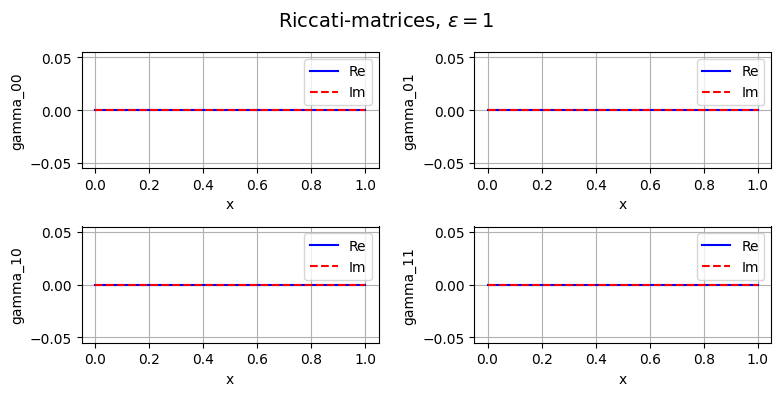

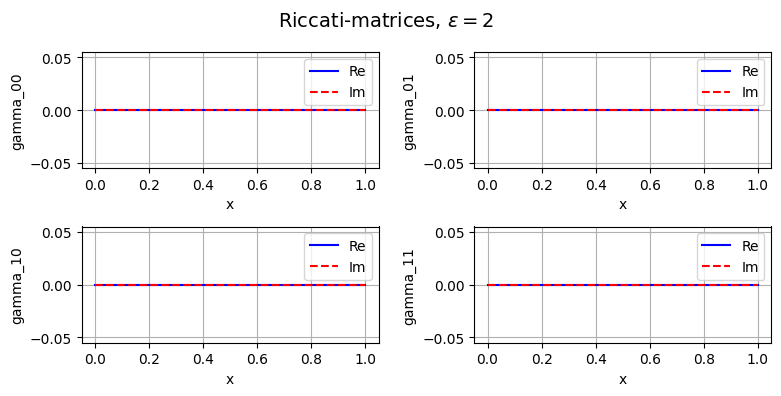

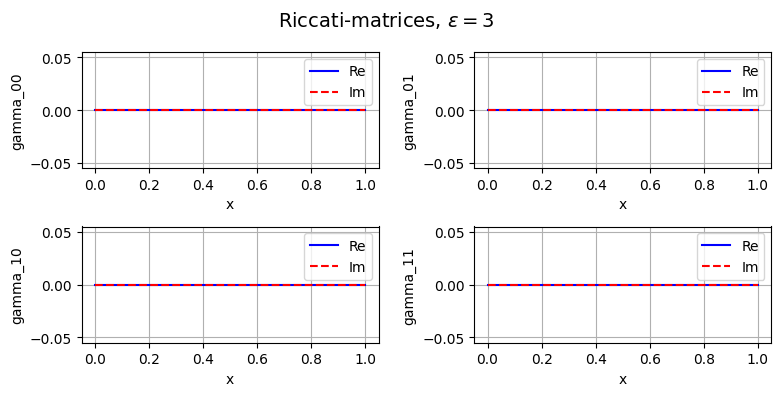

In [ ]:
l = 1.0
m = 101
zeta = 3.0
delta = 0.01
epsilon_arr = np.array([1, 2, 3])

n_matrices = 4
matrix_shape = (2, 2)



for epsilon in epsilon_arr:
    x = np.linspace(0, l, m)
    y = np.zeros((32, m))

    sol = solve_bvp(make_diff_system(epsilon, delta, matrix_shape, n_matrices), make_bc(zeta, l, matrix_shape, n_matrices), x, y)

    x_plot = np.linspace(0, l, m)
    v_sol = sol.sol(x_plot)

    fig, ax = plt.subplots(*matrix_shape,  figsize = (8, 4))
    fig.suptitle(r'Riccati-matrices, $\epsilon =$'+ f'{epsilon}', fontsize=14)
    
    n_entries = np.prod(matrix_shape)
    gamma_components = [v_sol[i] + 1j * v_sol[i + n_entries] for i in range(n_entries)]
    
    for i, comp in enumerate([gamma for gamma in gamma_components]):
        row = i // matrix_shape[1]
        col = i % matrix_shape[1]
        
        ax[row][col].plot(x_plot, np.real(comp), 'b-', label = "Re")
        ax[row][col].plot(x_plot, np.imag(comp), 'r--', label = "Im")
        ax[row][col].set_xlabel('x')
        ax[row][col].set_ylabel(f"gamma_{row}{col}")
        ax[row][col].legend()
        ax[row][col].grid()
    
    plt.tight_layout()
    plt.show()    

#### h)

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 2 and the array at index 1 has size 1

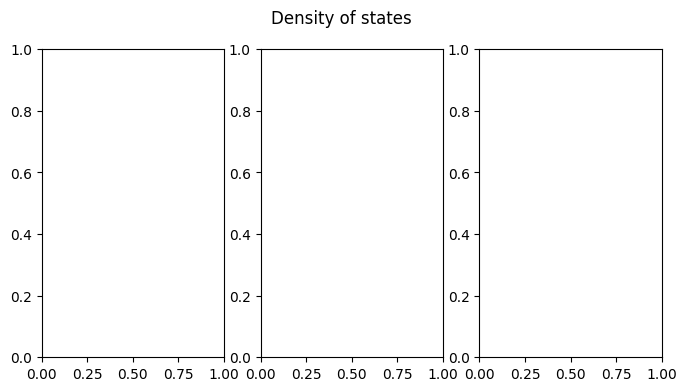

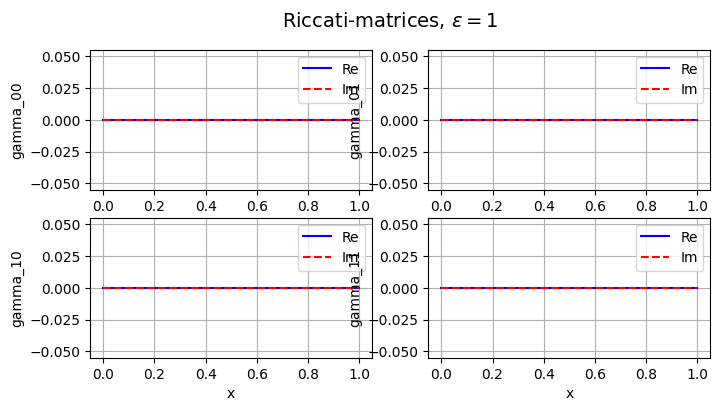

In [ ]:
def greens_fun(gamma, gamma_tilde, matrix_shape):
    N = find_N(gamma, gamma_tilde, False)
    N_tilde = find_N(gamma, gamma_tilde, True)
        
    return np.matrix([[2 * N - np.eye(matrix_shape[0]), 2 * N @ gamma], [-2 * N_tilde @ gamma_tilde, -2 * N_tilde + np.eye(matrix_shape[0])]])

def DOS_fun(gamma, gamma_tilde, matrix_shape):
    greens = greens_fun(gamma, gamma_tilde, matrix_shape)
    rho_3 = np.matrix([[np.eye(matrix_shape[0]), np.zeros(matrix_shape[0])], [np.zeros(matrix_shape[0]), -np.eye(matrix_shape[0])]])
    
    return np.real(np.trace(rho_3 @ greens))/4

def normal_metal_sol(l, m, zeta, delta, epsilon_arr, n_matrices, matrix_shape):
    fig2, ax2 = plt.subplots(1, len(epsilon_arr), figsize = (8, 4))
    fig2.suptitle('Density of states')
    
    for j, epsilon in enumerate(epsilon_arr):
        x = np.linspace(0, l, m)
        y = np.zeros((32, m))

        sol = solve_bvp(make_diff_system(epsilon, delta, matrix_shape, n_matrices), make_bc(zeta, l, matrix_shape, n_matrices), x, y)

        x_plot = np.linspace(0, l, m)
        v_sol = sol.sol(x_plot)

        fig1, ax1 = plt.subplots(*matrix_shape,  figsize = (8, 4))
        ax1 = np.atleast_2d(ax1) #claude here
        fig1.suptitle(r'Riccati-matrices, $\epsilon =$'+ f'{epsilon}', fontsize=14)
        
        n_entries = np.prod(matrix_shape)
        components = [v_sol[i] + 1j * v_sol[i + n_entries] for i in range(n_entries)]
        
        for i, comp in enumerate([component for component in components]):
            row = i // matrix_shape[1]
            col = i % matrix_shape[1]
            
            ax1[row][col].plot(x_plot, np.real(comp), 'b-', label = "Re")
            ax1[row][col].plot(x_plot, np.imag(comp), 'r--', label = "Im")
            ax1[row][col].set_xlabel('x')
            ax1[row][col].set_ylabel(f"gamma_{row}{col}")
            ax1[row][col].legend()
            ax1[row][col].grid()
        
        
        
        DOS = np.array([
            DOS_fun(*usadel_vec_to_matrix(v_sol[:, k], matrix_shape, n_matrices)[:2], matrix_shape)
            for k in range(v_sol.shape[1])
        ])
        
        ax2[j].plot(x_plot, DOS, label = f"epsilon = {epsilon}")
        ax2[j].set_xlabel('x')
        ax2[j].set_ylabel('DOS')
        ax2[j].legend()
        ax2[j].grid()
        
        plt.tight_layout()
        plt.show()    

normal_metal_sol(l, m, zeta, delta, epsilon_arr, n_matrices, matrix_shape)


千里之行，始于足下

change N to simply return N and N_tilde